In [38]:
import pandas as pd
import numpy as np

# === STEP 1: Load a sample of your data ===
file = "/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 3/trimet_stop_event_2023_2024.csv"
columns = ['LEAVE_TIME', 'STOP_TIME', 'LATITUDE', 'LONGITUDE', 'ROUTE_NUMBER', 'ONS', 'OFFS']
df = pd.read_csv(file, usecols=columns, nrows=500000)

# === EXCLUDE 900-series ghost routes ===
df = df[df['ROUTE_NUMBER'] < 900]

# === STEP 2: Calculate OTP flag ===
df['DELAY_MINUTES'] = (df['LEAVE_TIME'] - df['STOP_TIME']) / 60
df['is_OTP'] = df['DELAY_MINUTES'].between(-1, 5).astype(int)

# === STEP 2.5: Extract Hour and Time of Day Group ===
df['LEAVE_HOUR'] = df['LEAVE_TIME'] // 3600  # LEAVE_TIME is in seconds, convert to hour
df['time_of_day'] = pd.cut(
    df['LEAVE_HOUR'],
    bins=[0, 6, 10, 15, 19, 24],
    labels=['Night', 'AM Peak', 'Midday', 'PM Peak', 'Evening'],
    right=False,
    include_lowest=True
)

# === STEP 3: Group by exact location and calculate OTP % and average load ===
location_otp = df.groupby(['LATITUDE', 'LONGITUDE']).agg(
    otp_rate=('is_OTP', 'mean'),
    avg_ons=('ONS', 'mean'),
    avg_offs=('OFFS', 'mean'),
    total_ons=('ONS', 'sum'),
    total_offs=('OFFS', 'sum'),
    count=('is_OTP', 'count')
).reset_index()

print("\n🏆 BEST OTP 2023-2024 LOCATIONS (with load):")
print(best_locations[['LATITUDE', 'LONGITUDE', 'otp_rate', 'avg_ons', 'avg_offs', 'count']])

print("\n⚠️ WORST OTP 2023-2024 LOCATIONS (with load):")
print(worst_locations[['LATITUDE', 'LONGITUDE', 'otp_rate', 'avg_ons', 'avg_offs', 'count']])


# Filter for meaningful locations (e.g., at least 50 stop events)
location_otp = location_otp[location_otp['count'] >= 50]

# === STEP 4: Find best and worst performing stop locations ===
best_locations = location_otp.sort_values('otp_rate', ascending=False).head(10)
worst_locations = location_otp.sort_values('otp_rate', ascending=True).head(10)

# === STEP 5: Display results ===
print("\n🏆 BEST OTP 2023-2024 LOCATIONS:")
print(best_locations[['LATITUDE', 'LONGITUDE', 'otp_rate', 'count']])

print("\n⚠️ WORST OTP 2023-2024 LOCATIONS:")
print(worst_locations[['LATITUDE', 'LONGITUDE', 'otp_rate', 'count']])

# === STEP 6: Filter just the worst stop locations from df ===
worst_coords = worst_locations[['LATITUDE', 'LONGITUDE']]
df_worst = df.merge(worst_coords, on=['LATITUDE', 'LONGITUDE'], how='inner')

# === STEP 7: OTP by time of day at worst-performing stops ===
otp_by_time = df_worst.groupby('time_of_day', observed=True).agg(
    otp_rate=('is_OTP', 'mean'),
    trip_count=('is_OTP', 'count')
).reset_index()


print("\n📊 OTP by Time of Day at Worst Locations 2023-2024:")
print(otp_by_time)

# === STEP 8: Analyze Route Numbers at Worst Performing Locations ===
routes_at_worst = df_worst.groupby('ROUTE_NUMBER').agg(
    otp_rate=('is_OTP', 'mean'),
    stop_count=('is_OTP', 'count')
).reset_index()

# Optional: Filter for routes with at least 25 trips at these locations
routes_at_worst = routes_at_worst[routes_at_worst['stop_count'] >= 25]

# Sort by lowest OTP rate
routes_at_worst = routes_at_worst.sort_values('otp_rate')

print("\n🚍 ROUTES AT WORST-OTP 2023-2024 LOCATIONS:")
print(routes_at_worst.head(10))

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# === STEP 9: Reverse Geocode Worst OTP Stops (updated to extract neighborhoods) ===
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="trimet-otp-neighborhoods")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)

# Create 'neighborhood' column directly from raw address components
def extract_neighborhood(lat, lon):
    try:
        location = geocode((lat, lon), exactly_one=True, language="en")
        if location and location.raw:
            return (
                location.raw.get('address', {}).get('neighbourhood') or
                location.raw.get('address', {}).get('suburb') or
                location.raw.get('address', {}).get('city_district') or
                "Unknown"
            )
    except:
        return "Unknown"

# Apply to worst-performing stop locations
worst_locations_geo = worst_locations.copy()
worst_locations_geo['neighborhood'] = worst_locations_geo.apply(
    lambda row: extract_neighborhood(row['LATITUDE'], row['LONGITUDE']), axis=1
)

# Show result
print("\n📍 Top 10 Worst OTP Stops with Neighborhoods (2023-2024):")
print(worst_locations_geo[['LATITUDE', 'LONGITUDE', 'otp_rate', 'count', 'neighborhood']])



# === STEP 10: Group by neighborhood and analyze OTP vs load ===
neighborhood_summary = worst_locations_geo.groupby('neighborhood').agg(
    otp_rate=('otp_rate', 'mean'),
    avg_ons=('avg_ons', 'mean'),
    avg_offs=('avg_offs', 'mean'),
    total_stops=('count', 'sum')
).reset_index()

# Sort to get Top 10 and Bottom 10 neighborhoods by OTP
top_10 = neighborhood_summary.sort_values('otp_rate', ascending=False).head(10)
bottom_10 = neighborhood_summary.sort_values('otp_rate').head(10)

print("\n🏆 Top 10 Neighborhoods by OTP:")
print(top_10)

print("\n⚠️ Bottom 10 Neighborhoods by OTP:")
print(bottom_10)



🏆 BEST OTP 2023-2024 LOCATIONS (with load):
       LATITUDE   LONGITUDE  otp_rate   avg_ons  avg_offs  count
3130  45.500224 -122.881045       1.0  0.058824  0.039216     51
3406  45.507207 -122.880779       1.0  0.153846  0.134615     52
3610  45.513390 -122.879632       1.0  0.058824  0.019608     51
3637  45.514394 -122.879605       1.0  0.096154  0.057692     52
3695  45.516076 -122.876760       1.0  0.117647  0.039216     51
3293  45.504539 -122.880844       1.0  0.096154  0.057692     52
3200  45.502411 -122.880966       1.0  0.098039  0.000000     51
4898  45.536755 -122.705091       1.0  0.490909  0.072727     55
201   45.362771 -122.598486       1.0  0.195652  0.021739     92
3453  45.508530 -122.879610       1.0  0.176471  0.176471     51

⚠️ WORST OTP 2023-2024 LOCATIONS (with load):
       LATITUDE   LONGITUDE  otp_rate   avg_ons  avg_offs  count
2776  45.492430 -122.475699  0.291667  0.000000  0.875000     72
5646  45.558119 -122.564970  0.320000  0.000000  1.260000     5

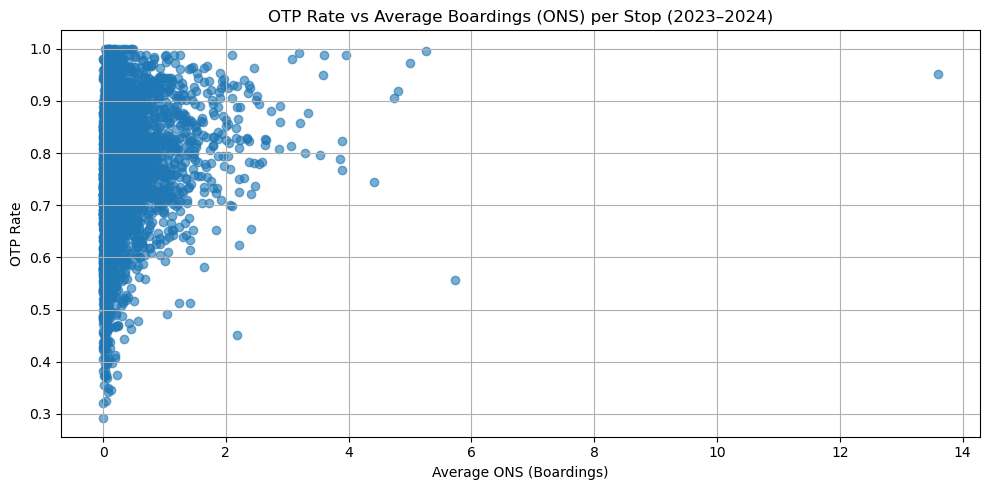

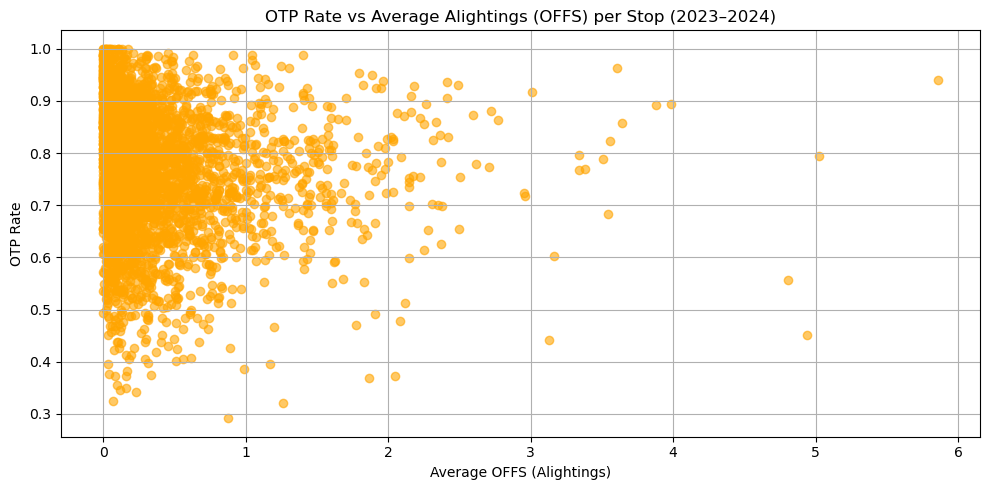

In [32]:
import matplotlib.pyplot as plt

# === Visual 1: avg_ons vs otp_rate ===
plt.figure(figsize=(10, 5))
plt.scatter(location_otp['avg_ons'], location_otp['otp_rate'], alpha=0.6)
plt.title('OTP Rate vs Average Boardings (ONS) per Stop (2023–2024)')
plt.xlabel('Average ONS (Boardings)')
plt.ylabel('OTP Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# === Visual 2: avg_offs vs otp_rate ===
plt.figure(figsize=(10, 5))
plt.scatter(location_otp['avg_offs'], location_otp['otp_rate'], alpha=0.6, color='orange')
plt.title('OTP Rate vs Average Alightings (OFFS) per Stop (2023–2024)')
plt.xlabel('Average OFFS (Alightings)')
plt.ylabel('OTP Rate')
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
# === Find stops with high avg_ons and low OTP ===
low_otp_high_ons = location_otp[
    (location_otp['avg_ons'] > 1) & (location_otp['otp_rate'] < 0.6)
].sort_values('otp_rate')

print("\n⚠️ Stops with High Boardings & Low OTP:")
print(low_otp_high_ons[['LATITUDE', 'LONGITUDE', 'otp_rate', 'avg_ons', 'avg_offs', 'count']].head(10))

# === Find stops with high avg_offs and low OTP ===
low_otp_high_offs = location_otp[
    (location_otp['avg_offs'] > 1) & (location_otp['otp_rate'] < 0.6)
].sort_values('otp_rate')

print("\n⚠️ Stops with High Alightings & Low OTP 2023-2024:")
print(low_otp_high_offs[['LATITUDE', 'LONGITUDE', 'otp_rate', 'avg_ons', 'avg_offs', 'count']].head(10))



⚠️ Stops with High Boardings & Low OTP:
       LATITUDE   LONGITUDE  otp_rate   avg_ons  avg_offs  count
3719  45.516403 -122.679839  0.451220  2.176829  4.939024    164
6143  45.586992 -122.738230  0.492063  1.047619  1.904762    126
1254  45.442534 -122.640041  0.512195  1.422764  0.894309    123
3954  45.519467 -123.004624  0.512346  1.234568  0.802469    162
6157  45.588021 -122.593171  0.557377  5.729508  4.803279    122
2960  45.497021 -122.808619  0.581967  1.639344  0.795082    122

⚠️ Stops with High Alightings & Low OTP 2023-2024:
       LATITUDE   LONGITUDE  otp_rate   avg_ons  avg_offs  count
5646  45.558119 -122.564970  0.320000  0.000000  1.260000     50
3230  45.503181 -122.426298  0.368000  0.064000  1.864000    125
3664  45.515359 -122.681597  0.372881  0.016949  2.050847     59
3974  45.519735 -123.114234  0.395062  0.055556  1.172840    162
5651  45.558368 -122.564954  0.440860  0.086022  3.129032     93
3719  45.516403 -122.679839  0.451220  2.176829  4.939024    1

In [36]:
from scipy.stats import chi2_contingency

# === 1. Create manual bins for ONS ===
df['load_group_ons'] = np.where(df['ONS'] == 0, 'Zero ONS', 'Some ONS')

# === 2. Chi-square test: ONS vs OTP ===
contingency_ons = pd.crosstab(df['load_group_ons'], df['is_OTP'])
chi2_ons, p_ons, _, _ = chi2_contingency(contingency_ons)

print("\n📊 Chi-Square Test: ONS (Zero vs Some) vs OTP")
print("Contingency Table:\n", contingency_ons)
print(f"Chi-square = {chi2_ons:.2f}, p-value = {p_ons:.4f}")

# === 3. Create manual bins for OFFS ===
df['load_group_offs'] = np.where(df['OFFS'] == 0, 'Zero OFFS', 'Some OFFS')

# === 4. Chi-square test: OFFS vs OTP ===
contingency_offs = pd.crosstab(df['load_group_offs'], df['is_OTP'])
chi2_offs, p_offs, _, _ = chi2_contingency(contingency_offs)

print("\n📊 Chi-Square Test: OFFS (Zero vs Some) vs OTP")
print("Contingency Table:\n", contingency_offs)
print(f"Chi-square = {chi2_offs:.2f}, p-value = {p_offs:.4f}")



📊 Chi-Square Test: ONS (Zero vs Some) vs OTP
Contingency Table:
 is_OTP              0       1
load_group_ons               
Some ONS        19652   81573
Zero ONS        94524  287347
Chi-square = 1263.27, p-value = 0.0000

📊 Chi-Square Test: OFFS (Zero vs Some) vs OTP
Contingency Table:
 is_OTP               0       1
load_group_offs               
Some OFFS        28134   72829
Zero OFFS        86042  296091
Chi-square = 1265.94, p-value = 0.0000
